## 1. Intro

### Goals, questions, imports [...]

In [1]:
import pandas as pd

feelings_review_dataset = '../utils/feelings_review/Reviews.csv'

df = pd.read_csv(feelings_review_dataset)

pd.set_option('display.max_columns', None)

## 2. Loading and understanding the data

### Load, info, describe, basic visualization

In [2]:
# Basic dataframe info
df.info()
df.head()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


## 3. Cleaning and Pre processing

### Remove duplicated data and cleaning the text

<b>Part 1:</b>

[✅] <b>Create column 'Target'</b> for positive (score >= 4) and negative (score <= 2) reviews

[✅] <b>Verify:</b> size, duplicated values, class distribution

[✅] <b>Cell with statistics:</b> shape, columns, % of any missing data

[✅] <b>Graph:</b> score distribution (1-5)


In [3]:
df['target'] = df['Score'].apply(lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else None))

# removing any NaN/Null values in case of the value does not fit inside the logic.
df = df.dropna(subset=['target'])

print("****** Dataframe Size **********************************")
print(len(df))
print("")

get_duplicated_values = df.duplicated().sum()

print("****** Number of Duplicated Values *********************")
print(get_duplicated_values)
print("")

class_distribution = df['target']
print("****** Class Distribution at target column (in %) ******")
print(class_distribution.value_counts(normalize=True) * 100)

df.head()

****** Dataframe Size **********************************
525814

****** Number of Duplicated Values *********************
0

****** Class Distribution at target column (in %) ******
target
positive    84.398095
negative    15.601905
Name: proportion, dtype: float64


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,target
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,negative
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,positive


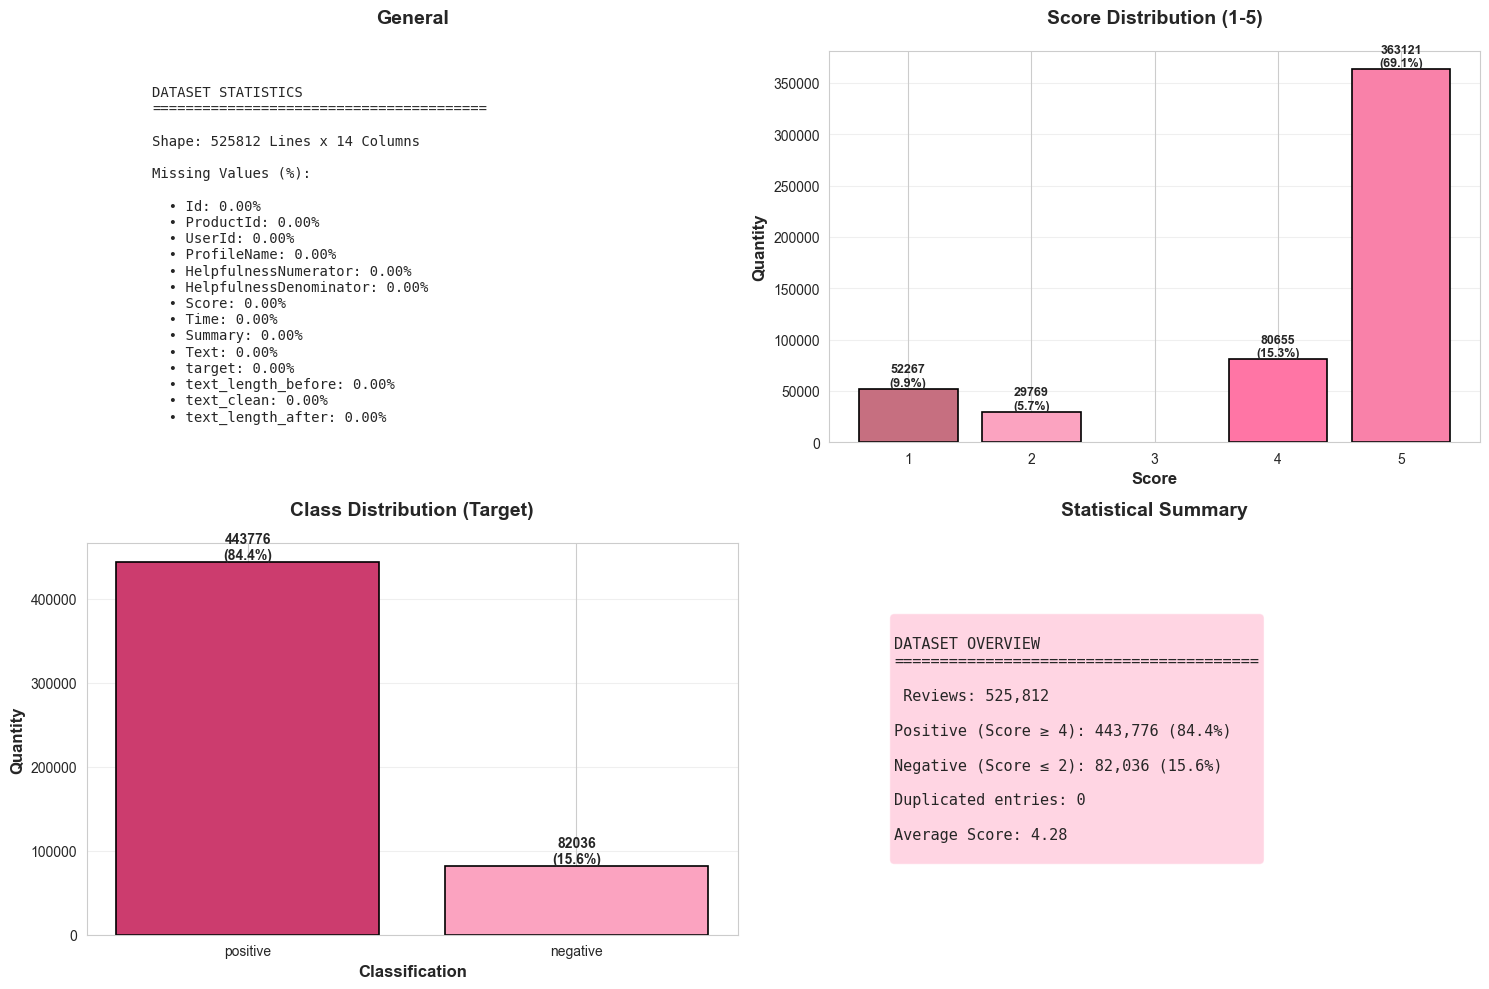

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.axis('off')
stats_text = f"""
DATASET STATISTICS
{'='*40}

Shape: {df.shape[0]} Lines x {df.shape[1]} Columns

Missing Values (%):
"""
for col in df.columns:
    missing_pct = (df[col].isna().sum() / len(df)) * 100
    stats_text += f"\n  • {col}: {missing_pct:.2f}%"

plt.text(0.1, 0.5, stats_text, fontsize=10, family='monospace', 
         verticalalignment='center')
plt.title('General', fontsize=14, fontweight='bold', pad=20)

# Score Distribution (1-5)
plt.subplot(2, 2, 2)
score_counts = df['Score'].value_counts().sort_index()
colors = ['#c66f80', '#fba3c0', '#ff75a5', '#f981a9', '#cc3c6e']
bars = plt.bar(score_counts.index, score_counts.values, color=colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xlabel('Score', fontsize=12, fontweight='bold')
plt.ylabel('Quantity', fontsize=12, fontweight='bold')
plt.title('Score Distribution (1-5)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(range(1, 6))
plt.grid(axis='y', alpha=0.3)

# Distribution of column 'Target'
plt.subplot(2, 2, 3)
target_counts = df['target'].value_counts()
colors = ['#cc3c6e', '#fba3c0']
bars = plt.bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Classification', fontsize=12, fontweight='bold')
plt.ylabel('Quantity', fontsize=12, fontweight='bold')
plt.title('Class Distribution (Target)', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# Overview
plt.subplot(2, 2, 4)
plt.axis('off')
summary_text = f"""
DATASET OVERVIEW
{'='*40}

 Reviews: {len(df):,}

Positive (Score ≥ 4): {(df['target'] == 'positive').sum():,} ({(df['target'] == 'positive').sum()/len(df)*100:.1f}%)

Negative (Score ≤ 2): {(df['target'] == 'negative').sum():,} ({(df['target'] == 'negative').sum()/len(df)*100:.1f}%)

Duplicated entries: {get_duplicated_values:,}

Average Score: {df['Score'].mean():.2f}
"""
plt.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='#ff75a5', alpha=0.3))
plt.title('Statistical Summary', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

<b>Skills</b>: Data ingestion, initial analysis, basic visualization.

<hr />

<b>Part 2:</b>

[✅] <b>Remove duplicated values:</b> `df.drop_duplicates()`

[✅] <b>Filter small text entries:</b> `df[df['Text'].str.len() > 20]`

[✅] <b>Create cell with function to clean this text:</b> and apply to text column
  - Lower all data
  - Remove pontuation
  - Remove URLs

[✅] Create column `text_clean`

[✅] <b>Histogram:</b> size of the text before/after

Cleaning text...


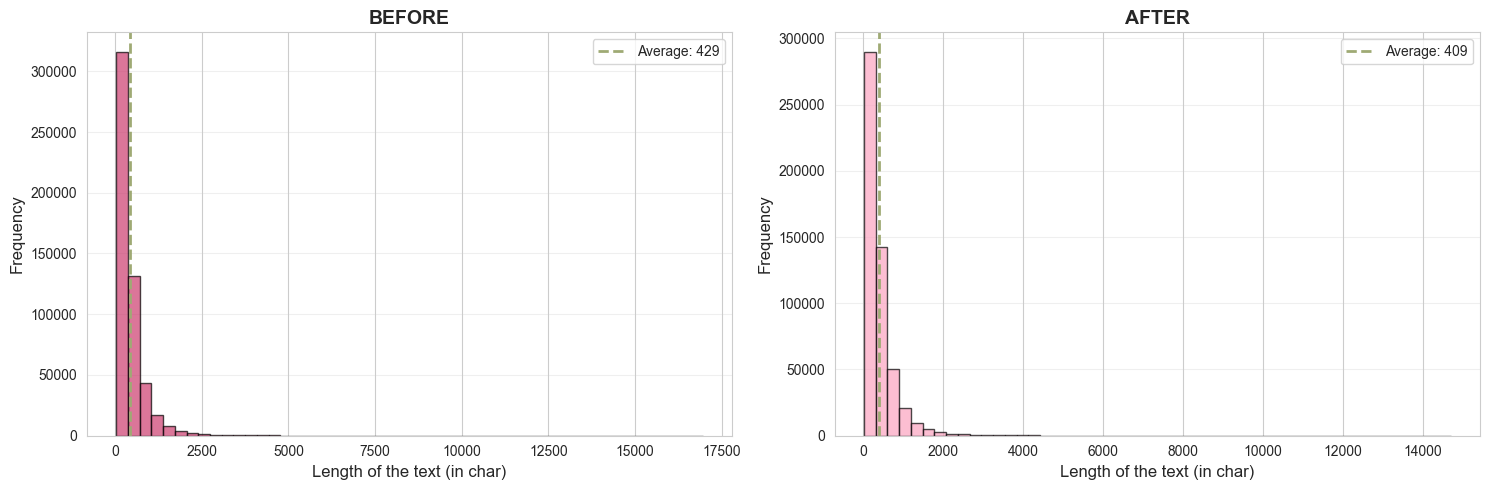

In [14]:
import re
import string
import matplotlib.pyplot as plt

df = df.drop_duplicates()
df = df[df['Text'].str.len() > 20]

df['text_length_before'] = df['Text'].str.len()

url_pattern = re.compile(r'https?://\S+|www\.\S+')
whitespace_pattern = re.compile(r'\s+')
translator = str.maketrans('', '', string.punctuation)

def clean_text(text):
    text = text.lower()
    text = url_pattern.sub('', text)
    text = text.translate(translator)
    text = whitespace_pattern.sub(' ', text).strip()
    return text

print("Cleaning text...")
df['text_clean'] = [clean_text(text) for text in df['Text']]

df['text_length_after'] = df['text_clean'].str.len()

df.head()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# text BEFORE
axes[0].hist(df['text_length_before'], bins=50, color='#cc3c6e', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Length of the text (in char)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('BEFORE', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvline(df['text_length_before'].mean(), color='#9faa74', linestyle='--',
                linewidth=2, label=f'Average: {df["text_length_before"].mean():.0f}')
axes[0].legend()

# text AFTER
axes[1].hist(df['text_length_after'], bins=50, color='#fba3c0', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Length of the text (in char)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('AFTER', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axvline(df['text_length_after'].mean(), color='#9faa74', linestyle='--',
                linewidth=2, label=f'Average: {df["text_length_after"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()



Before cleaning the text:
  • **Average**: 429 characters;
  • **Minimum** of: 27 characters;
  • **Maximum** of: 16952 characters.

After cleaning the text:
  • **Average**: 409 characters
  • **Minimum**: 22 characters
  • **Maximum**: 14704 characters

Average reduction of characters: 20 characters (4.7%)

<b>Skills</b>: Text cleaning, string manipulation, transformations.

<hr />

## 4. Exploratory Data Analysis (EDA)

### Distribution, WordClouds, Top Words

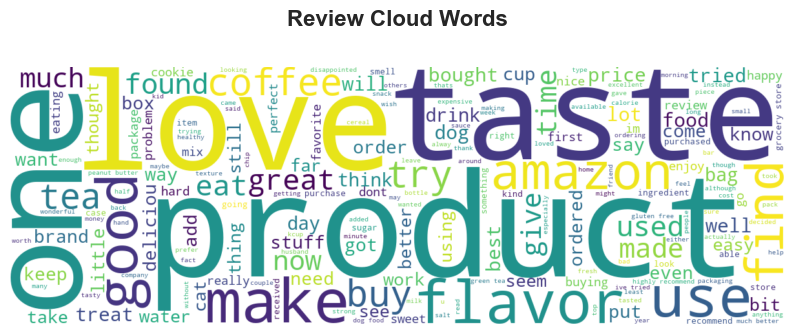

In [23]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

stopwords = set(STOPWORDS)
stopwords.update([])

text = ' '.join(df['text_clean'])

wordcloud = WordCloud(
    width=1200,
    height=400,
    background_color='white',
    max_words=200,
    stopwords=stopwords
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(label='Review Cloud Words', pad=30, fontsize=16, fontweight='bold')
plt.show()



## 5. Engenharia de Features

### TF-IDF, preparação dos dados

## 6. Modelagem

### Treino de 3 modelos, comparação

## 7. Avaliação

### Métricas, matriz confusão, ROC

## 8. Explicabilidade

### Importância de features, LIME

## 9. Storytelling e Conclusões

### Narrativa final, insights, recomendações